© 2025 Mobile Perception Systems Lab at TU/e. All rights reserved. Licensed under the MIT License.

## Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
cd /content/drive/MyDrive/AnomalySegmentation_Project/eomt

/content/drive/MyDrive/AnomalySegmentation_Project/eomt


In [3]:
!pip install -r requirements.txt

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 5.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 7.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 5.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.3/131.3 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 118.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 112.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 156.5 MB/

In [ ]:
import yaml
from lightning import seed_everything
import torch
from torch.nn import functional as F
from torch.amp.autocast_mode import autocast
import matplotlib.pyplot as plt
import numpy as np
from huggingface_hub import hf_hub_download
from huggingface_hub.utils import RepositoryNotFoundError
import warnings
import importlib

seed_everything(0, verbose=False)

device = 1  # TODO: change to the GPU you want to use
img_idx = 175 # TODO: change to the index of the image you want to visualize
config_path_coco = "configs/dinov2/coco/panoptic/eomt_base_640_2x.yaml"
config_path_cityscapes = "configs/dinov2/cityscapes/semantic/eomt_base_640.yaml"
data_path = "../Cityscapes"  # TODO: change to the dataset directory

with open(config_path_coco, "r") as f:
    config_coco = yaml.safe_load(f)

with open(config_path_cityscapes, "r") as f:
    config_city = yaml.safe_load(f)

def create_mapping(images, ignore_index):
    unique_ids = np.unique(np.concatenate([np.unique(img) for img in images]))
    valid_ids = unique_ids[unique_ids != ignore_index]
    colors = np.array(
        [plt.cm.hsv(i / len(valid_ids))[:3] for i in range(len(valid_ids))]
    )
    mapping = {cid: colors[i] for i, cid in enumerate(valid_ids)}
    mapping[ignore_index] = np.array([0, 0, 0])
    return mapping


def apply_colormap(image, mapping):
    colored_image = np.zeros((*image.shape, 3))
    for cid in np.unique(image):
        colored_image[image == cid] = mapping.get(cid, [0, 0, 0])
    return colored_image

In [ ]:
# Check if CUDA (NVIDIA GPU) is available
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"GPU detected: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("No GPU detected, using CPU.")


GPU detected: NVIDIA L4


## Load dataset

Ensure the dataset files are correctly prepared and placed in the folder specified by `data_path`.

In [ ]:
#CITYSCAPES
data_module_name_city, class_name_city = config_city["data"]["class_path"].rsplit(".", 1)
data_module_city = getattr(importlib.import_module(data_module_name_city), class_name_city)
data_kwargs_city = config_city["data"].get("init_args", {})

data_city = data_module_city(
    path=data_path,
    batch_size=1,
    num_workers=0,
    check_empty_targets=False,
    **data_kwargs_city
)
data_city.setup()


#COCO
data_module_name_coco, class_name_coco = config_coco["data"]["class_path"].rsplit(".", 1)
data_module_coco = getattr(importlib.import_module(data_module_name_coco), class_name_coco)
data_kwargs_coco = config_coco["data"].get("init_args", {})

data_coco_meta = data_module_coco(
    path="",
    batch_size=1,
    num_workers=0,
    check_empty_targets=False,
    **data_kwargs_coco
)

## Load model

In [ ]:
warnings.filterwarnings(
    "ignore",
    message=r".*Attribute 'network' is an instance of `nn\.Module` and is already saved during checkpointing.*",
)

def build_and_load_model(config, data_meta, weights_path):
    # Load encoder
    encoder_cfg = config["model"]["init_args"]["network"]["init_args"]["encoder"]
    encoder_module_name, encoder_class_name = encoder_cfg["class_path"].rsplit(".", 1)
    encoder_cls = getattr(importlib.import_module(encoder_module_name), encoder_class_name)
    encoder = encoder_cls(img_size=data_meta.img_size, **encoder_cfg.get("init_args", {}))

    # Load network
    network_cfg = config["model"]["init_args"]["network"]
    network_module_name, network_class_name = network_cfg["class_path"].rsplit(".", 1)
    network_cls = getattr(importlib.import_module(network_module_name), network_class_name)
    network_kwargs = {k: v for k, v in network_cfg["init_args"].items() if k != "encoder"}

    network = network_cls(
        masked_attn_enabled=False,
        num_classes=data_meta.num_classes,
        encoder=encoder,
        **network_kwargs,
    )

    # Load Lightning module
    lit_module_name, lit_class_name = config["model"]["class_path"].rsplit(".", 1)
    lit_cls = getattr(importlib.import_module(lit_module_name), lit_class_name)
    model_kwargs = {k: v for k, v in config["model"]["init_args"].items() if k != "network"}

    if "stuff_classes" in config["data"].get("init_args", {}):
        model_kwargs["stuff_classes"] = config["data"]["init_args"]["stuff_classes"]

    name = config.get("trainer", {}).get("logger", {}).get("init_args", {}).get("name", "")
    is_dinov3 = "dinov3" in name

    if is_dinov3:
        model_kwargs["ckpt_path"] = weights_path
        model_kwargs["delta_weights"] = True

    model = (
        lit_cls(
            img_size=data_meta.img_size,
            num_classes=data_meta.num_classes,
            network=network,
            **model_kwargs,
        )
        .eval()
        .to(device)
    )

    if not is_dinov3:
        try:
            state_dict = torch.load(weights_path, map_location=device, weights_only=True)
            model.load_state_dict(state_dict, strict=False)
            print(f"Weights successfully loaded from {weights_path}!")
        except Exception as e:
            print(f"Error loading weights from {weights_path}: {e}")

    return model

#COCO
state_dict_path_coco = "weights/eomt_coco.bin"
print("Initializing COCO Panoptic model...")
model_panoptic = build_and_load_model(config_coco, data_coco_meta, state_dict_path_coco)

#CITYSCAPES
state_dict_path_city = "weights/eomt_cityscapes.bin"
print("Initializing Cityscapes Semantic model...")
model_semantic = build_and_load_model(config_city, data_city, state_dict_path_city)

Initializing COCO Panoptic model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Weights successfully loaded from weights/eomt_coco.bin!
Initializing Cityscapes Semantic model...
Weights successfully loaded from weights/eomt_cityscapes.bin!


## Semantic inference (pixel-wise classification)

> This inference method also works when applied to a model trained for panoptic segmentation.

Semantic inference computes per-pixel class scores by combining mask and class predictions:

$$
\sum_i p_i(c) \cdot m_i[h, w]
$$

Here, $p_i(c)$ is the class probability for class $c$ (excluding "no object"), and $m_i[h, w]$ is the sigmoid-normalized mask value for query $i$ at pixel $(h, w)$. The final class is selected by taking the argmax over classes.  
  
*This inference method was originally introduced in MaskFormer.*

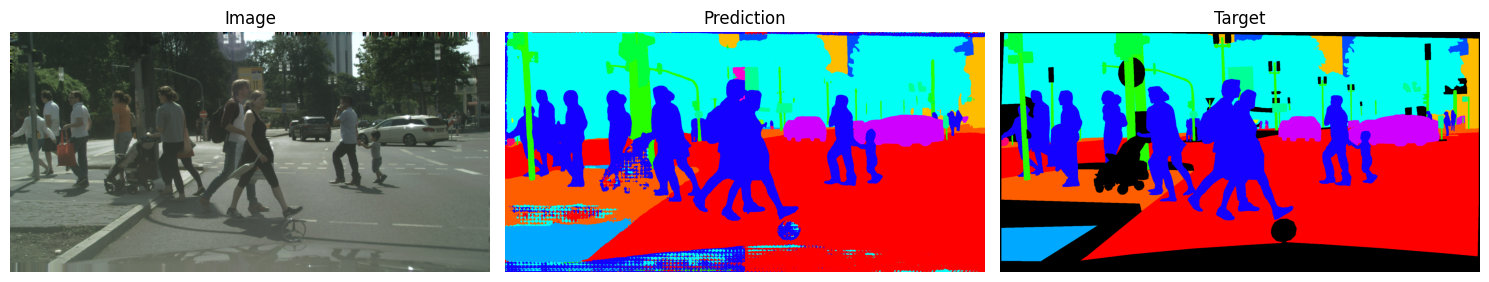

In [ ]:
IGNORE_INDEX = 255

def infer_semantic(model_sem, data_val, img, target):
    with torch.no_grad(), autocast(dtype=torch.float16, device_type="cuda"):
        imgs = [img.to(device)]
        img_sizes = [img.shape[-2:] for img in imgs]

        crops, origins = model_sem.window_imgs_semantic(imgs)

        mask_logits_per_layer, class_logits_per_layer = model_sem(crops)

        mask_logits = F.interpolate(
            mask_logits_per_layer[-1], data_val.img_size, mode="bilinear"
        )

        crop_logits = model_sem.to_per_pixel_logits_semantic(
            mask_logits, class_logits_per_layer[-1]
        )
        logits = model_sem.revert_window_logits_semantic(crop_logits, origins, img_sizes)
        preds = logits[0].argmax(0).cpu()

    pred_array = preds.numpy()
    target_array = model_sem.to_per_pixel_targets_semantic([target], IGNORE_INDEX)[
        0
    ].numpy()
    return pred_array, target_array


def plot_semantic_results(img, pred_array, target_array):
    mapping = create_mapping([pred_array, target_array], IGNORE_INDEX)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img.permute(1, 2, 0).cpu().numpy())
    axes[0].set_title("Image")
    axes[1].imshow(apply_colormap(pred_array, mapping))
    axes[1].set_title("Prediction")
    axes[2].imshow(apply_colormap(target_array, mapping))
    axes[2].set_title("Target")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

img, target = data_city.val_dataloader().dataset[img_idx]
pred_array, target_array = infer_semantic(model_semantic, data_city, img, target)
plot_semantic_results(img, pred_array, target_array)

## Panoptic inference (segmentation with instance IDs)

> This inference method also works when applied to a model trained for instance segmentation.

Panoptic inference assigns each pixel $[h, w]$ to the query $i$ that maximizes the product of class and mask confidence:

$$
p_i(c_i) \cdot m_i[h, w]
$$

where $c_i = \arg\max_c \, p_i(c)$ is the most likely class for query $i$. A pixel is assigned to a query only if both the class confidence and mask confidence are high. Pixels assigned to the same query form a segment labeled with $c_i$. "Stuff" segments with the same class are merged; "thing" segments are kept distinct using the query index. Low-confidence and heavily occluded predictions are filtered out.  
  
*This inference method was originally introduced in MaskFormer.*

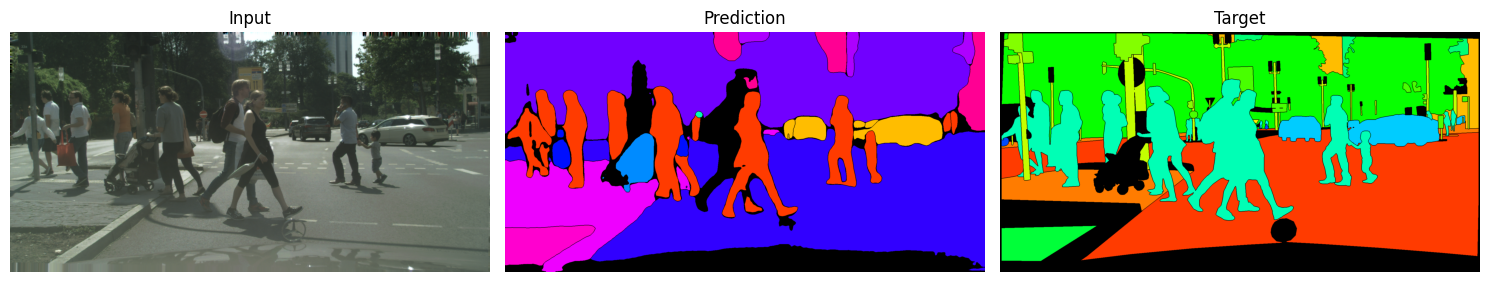

In [ ]:
def infer_panoptic(model_pan, img, target):
    with torch.no_grad(), autocast(dtype=torch.float16, device_type="cuda"):
        imgs = [img.to(device)]
        img_sizes = [img.shape[-2:] for img in imgs]

        transformed_imgs = model_pan.resize_and_pad_imgs_instance_panoptic(imgs)
        mask_logits_per_layer, class_logits_per_layer = model_pan(transformed_imgs)
        mask_logits = F.interpolate(
            mask_logits_per_layer[-1], model_pan.img_size, mode="bilinear"
        )
        mask_logits = model_pan.revert_resize_and_pad_logits_instance_panoptic(
            mask_logits, img_sizes
        )

        preds = model_pan.to_per_pixel_preds_panoptic(
            mask_logits,
            class_logits_per_layer[-1],
            model_pan.stuff_classes,
            model_pan.mask_thresh,
            model_pan.overlap_thresh,
        )[0].cpu()

    pred = preds.numpy()
    sem_pred, inst_pred = pred[..., 0], pred[..., 1]

    target_seg = model_pan.to_per_pixel_targets_panoptic([target])[0].cpu().numpy()
    sem_target, inst_target = target_seg[..., 0], target_seg[..., 1]

    return sem_pred, inst_pred, sem_target, inst_target


def draw_black_border(sem, inst, mapping):
    h, w = sem.shape
    out = np.zeros((h, w, 3))
    for s in np.unique(sem):
        out[sem == s] = mapping[s]

    combined = sem.astype(np.int64) * 100000 + inst.astype(np.int64)
    border = np.zeros((h, w), dtype=bool)
    border[1:, :] |= combined[1:, :] != combined[:-1, :]
    border[:-1, :] |= combined[1:, :] != combined[:-1, :]
    border[:, 1:] |= combined[:, 1:] != combined[:, :-1]
    border[:, :-1] |= combined[:, 1:] != combined[:, :-1]
    out[border] = 0
    return out


def plot_panoptic_results(img, sem_pred, inst_pred, sem_target, inst_target, num_classes):
    all_ids = np.union1d(np.unique(sem_pred), np.unique(sem_target))
    mapping = {
        s: (
            [0, 0, 0]
            if s == -1 or s == num_classes
            else plt.cm.hsv(i / len(all_ids))[:3]
        )
        for i, s in enumerate(all_ids)
    }

    vis_pred = draw_black_border(sem_pred, inst_pred, mapping)
    vis_target = draw_black_border(sem_target, inst_target, mapping)

    img_np = (
        img.cpu().numpy().transpose(1, 2, 0) if img.dim() == 3 else img.cpu().numpy()
    )

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img_np)
    axes[0].set_title("Input")
    axes[1].imshow(vis_pred)
    axes[1].set_title("Prediction")
    axes[2].imshow(vis_target)
    axes[2].set_title("Target")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


img, target = data_city.val_dataloader().dataset[img_idx]
sem_pred, inst_pred, sem_target, inst_target = infer_panoptic(model_panoptic, img, target)
plot_panoptic_results(img, sem_pred, inst_pred, sem_target, inst_target, model_panoptic.num_classes)

In [ ]:
from torchmetrics.classification import MulticlassJaccardIndex
from tqdm import tqdm

IGNORE_INDEX = 255

# 1. EVALUATION STRATEGY
# num_classes=20 (Indices 0-18: Cityscapes classes, Index 19: Sink class for errors and non-matching labels).
metric_city = MulticlassJaccardIndex(num_classes=20, ignore_index=IGNORE_INDEX, average="none").to(device)
metric_coco = MulticlassJaccardIndex(num_classes=20, ignore_index=IGNORE_INDEX, average="none").to(device)

# 2. CREATE AND POPULATE MAPPING TENSOR (Size 256 for crash prevention, initialized with 19)
mapping_tensor = torch.full((256,), 19, dtype=torch.long, device=device)

mapping_tensor[0] = 11   # person -> person
mapping_tensor[1] = 18   # bicycle -> bicycle
mapping_tensor[2] = 13   # car -> car
mapping_tensor[3] = 17   # motorcycle -> motorcycle

mapping_tensor[5] = 15   # bus -> bus
mapping_tensor[6] = 16   # train -> train
mapping_tensor[7] = 14   # truck -> truck

mapping_tensor[9] = 6    # traffic light -> traffic light

mapping_tensor[11] = 7   # stop sign -> traffic sign

mapping_tensor[86] = 2   # door-stuff -> building
mapping_tensor[87] = 9   # floor-wood -> terrain
mapping_tensor[88] = 8   # flower -> vegetation
mapping_tensor[91] = 2   # house -> building
mapping_tensor[96] = 2   # platform -> building
mapping_tensor[100] = 0  # road -> road
mapping_tensor[101] = 2  # roof -> building
mapping_tensor[102] = 9  # sand -> terrain


mapping_tensor[109] = 3  # wall-brick -> wall
mapping_tensor[110] = 3  # wall-stone -> wall
mapping_tensor[111] = 3  # wall-tile -> wall
mapping_tensor[112] = 3  # wall-wood -> wall
mapping_tensor[114] = 2  # window-blind -> building
mapping_tensor[115] = 2  # window-other -> building
mapping_tensor[116] = 8  # tree-merged -> vegetation
mapping_tensor[117] = 4  # fence-merged -> fence
mapping_tensor[119] = 10 # sky-other-merged -> sky
mapping_tensor[123] = 1 # pavement-merged -> sidewalk
mapping_tensor[129] = 2  # building-other -> building
mapping_tensor[131] = 3  # wall-other -> wall

mapping_tensor[116] = 8  # tree -> vegetation
mapping_tensor[125] = 8  # grass -> vegetation
mapping_tensor[88] = 8   # flower -> vegetation
mapping_tensor[90] = 9   # gravel -> terrain
mapping_tensor[102] = 9  # sand -> terrain
mapping_tensor[126] = 9  # dirt -> terrain

# 3. EVALUATION LOOP
val_dataloader = data_city.val_dataloader()

model_semantic.eval()
model_panoptic.eval()

print("Starting quantitative mIoU evaluation...")

for batch_idx, batch in enumerate(tqdm(val_dataloader, desc="Processing")):
    batched_imgs, batched_targets = batch
    img = batched_imgs[0]
    target = batched_targets[0]

    # --- Cityscapes Model (Native) ---
    preds_city_np, target_array_np = infer_semantic(model_semantic, data_city, img, target)

    preds_city_tensor = torch.tensor(preds_city_np, device=device)
    target_tensor = torch.tensor(target_array_np, device=device)
    metric_city.update(preds_city_tensor, target_tensor)

    # --- COCO Model (Mapped) ---
    preds_coco_np, _ = infer_semantic(model_panoptic, data_coco_meta, img, target)
    preds_coco_tensor = torch.tensor(preds_coco_np, device=device)

    # Instant vectorized mapping
    preds_mapped_tensor = mapping_tensor[preds_coco_tensor]
    metric_coco.update(preds_mapped_tensor, target_tensor)

# 4. RESULTS CALCULATION AND DISPLAY
iou_array_city = metric_city.compute()
iou_array_coco = metric_coco.compute()

# Definiamo il mapping completo basato su quello che hai inserito nel mapping_tensor
# Escludiamo 5 (pole) e 12 (rider) perché non sono mappati dal tuo codice COCO
class_info = [
    (0, "road"),
    (1, "sidewalk"),
    (2, "building"),
    (3, "wall"),
    (4, "fence"),
    (6, "traffic light"),
    (7, "traffic sign"),
    (8, "vegetation"),
    (9, "terrain"),
    (10, "sky"),
    (11, "person"),
    (13, "car"),
    (14, "truck"),
    (15, "bus"),
    (16, "train"),
    (17, "motorcycle"),
    (18, "bicycle")
]

all_mapped_ids = [info[0] for info in class_info]
names = [info[1] for info in class_info]

print("\n" + "="*75)
print(f"{'CLASS':<20} | {'Cityscapes IoU (%)':<22} | {'COCO Mapped IoU (%)':<20}")
print("-" * 75)

for cid, name in zip(all_mapped_ids, names):
    val_city = iou_array_city[cid].item() * 100
    val_coco = iou_array_coco[cid].item() * 100

    # Formattazione per gestire i NaN (se una classe non compare nel dataset)
    city_str = f"{val_city:>18.2f}" if not torch.isnan(iou_array_city[cid]) else f"{'N/A':>18}"
    coco_str = f"{val_coco:>18.2f}" if not torch.isnan(iou_array_coco[cid]) else f"{'N/A':>18}"

    print(f"{name:<20} | {city_str} | {coco_str}")

# Calcolo mIoU finale solo sulle classi effettivamente valutate
valid_city = iou_array_city[all_mapped_ids][~torch.isnan(iou_array_city[all_mapped_ids])]
valid_coco = iou_array_coco[all_mapped_ids][~torch.isnan(iou_array_coco[all_mapped_ids])]

miou_city = torch.mean(valid_city).item() * 100 if len(valid_city) > 0 else 0
miou_coco = torch.mean(valid_coco).item() * 100 if len(valid_coco) > 0 else 0

print("-" * 75)
print(f"{'TOTAL mIoU':<20} | {miou_city:>18.2f} | {miou_coco:>18.2f}")
print("=" * 75)

metric_city.reset()
metric_coco.reset()

Starting quantitative mIoU evaluation...


Processing: 100%|██████████| 500/500 [03:18<00:00,  2.51it/s]


CLASS                | Cityscapes IoU (%)     | COCO Mapped IoU (%) 
---------------------------------------------------------------------------
road                 |              98.40 |              94.01
sidewalk             |              87.36 |              64.75
building             |              94.15 |              87.04
wall                 |              66.07 |              45.77
fence                |              65.49 |              48.10
traffic light        |              75.00 |              60.38
traffic sign         |              82.13 |               4.41
vegetation           |              93.02 |              85.10
terrain              |              66.60 |               5.83
sky                  |              95.54 |              89.70
person               |              85.38 |              67.22
car                  |              95.54 |              84.22
truck                |              81.78 |              29.34
bus                  |             

In [7]:
!mkdir -p /content/Cityscapes_local
!cp /content/drive/MyDrive/AnomalySegmentation_Project/Cityscapes/*.zip /content/Cityscapes_local/

In [8]:
!wandb login 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

wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


Finetune only Head

In [ ]:
!python main.py fit \
  -c configs/dinov2/cityscapes/semantic/eomt_finetune_base.yaml \
  --data.batch_size 4   \
  --data.path /content/Cityscapes_local \
  --trainer.devices 1 \
  --trainer.logger.init_args.name "cityscapes_finetune_only_Head_batch4" \
  --trainer.logger.init_args.version "finetune_only_Head_batch4" \
  --model.network.init_args.unfreeze_last_n_blocks 0 \
  --model.load_ckpt_class_head False \
  --model.ckpt_path "./weights/eomt_coco.bin"

Output streaming troncato alle ultime 5000 righe.
                                     0:01:15                   losses/train_los…
Epoch 12/14 ━━━━━━━━━━━━━╺━━ 605/743 0:05:16 •        1.88it/s v_num: tch4      
                                     0:01:14                   losses/train_los…
Epoch 12/14 ━━━━━━━━━━━━━╺━━ 606/743 0:05:17 •        1.94it/s v_num: tch4      
                                     0:01:11                   losses/train_los…
Epoch 12/14 ━━━━━━━━━━━━━╺━━ 607/743 0:05:17 •        1.96it/s v_num: tch4      
                                     0:01:10                   losses/train_los…
Epoch 12/14 ━━━━━━━━━━━━━╺━━ 608/743 0:05:18 •        1.85it/s v_num: tch4      
                                     0:01:14                   losses/train_los…
Epoch 12/14 ━━━━━━━━━━━━━╺━━ 609/743 0:05:19 •        1.90it/s v_num: tch4      
                                     0:01:11                   losses/train_los…
Epoch 12/14 ━━━━━━━━━━━━━╺━━ 610/743 0:05:19 •        1.91i

Finetune Unfreeze 1

In [9]:
!python main.py fit \
  -c configs/dinov2/cityscapes/semantic/eomt_finetune_base.yaml \
  --data.batch_size 4 \
  --data.path /content/Cityscapes_local \
  --trainer.logger.init_args.name "cityscapes_finetune_unfreeze_1_4batch" \
  --trainer.logger.init_args.version "finetune_unfreeze_1_4batch" \
  --model.network.init_args.unfreeze_last_n_blocks 1 \
  --model.load_ckpt_class_head False \
  --model.ckpt_path "./weights/eomt_coco.bin"

Output streaming troncato alle ultime 5000 righe.
                                     0:01:13                   losses/train_los…
Epoch 12/14 ━━━━━━━━━━━━╸━━━ 601/743 0:05:12 •        2.01it/s v_num: atch      
                                     0:01:11                   losses/train_los…
Epoch 12/14 ━━━━━━━━━━━━╸━━━ 602/743 0:05:13 •        1.95it/s v_num: atch      
                                     0:01:13                   losses/train_los…
Epoch 12/14 ━━━━━━━━━━━━╸━━━ 602/743 0:05:13 •        1.95it/s v_num: atch      
                                     0:01:13                   losses/train_los…
Epoch 12/14 ━━━━━━━━━━━━╸━━━ 603/743 0:05:13 •        1.95it/s v_num: atch      
                                     0:01:12                   losses/train_los…
Epoch 12/14 ━━━━━━━━━━━━━╺━━ 604/743 0:05:14 •        2.02it/s v_num: atch      
                                     0:01:09                   losses/train_los…
Epoch 12/14 ━━━━━━━━━━━━━╺━━ 605/743 0:05:14 •        2.03i

Finetune Unfreeze 2 blocks

In [ ]:
!python main.py fit \
  -c configs/dinov2/cityscapes/semantic/eomt_finetune_base.yaml \
  --data.batch_size 4 \
  --data.path /content/Cityscapes_local \
  --trainer.devices 1 \
  --trainer.logger.init_args.name "cityscapes_unfreeze_2_batch4" \
  --trainer.logger.init_args.version "unfreeze_2_batch4" \
  --model.network.init_args.unfreeze_last_n_blocks 2 \
  --model.load_ckpt_class_head False \
  --model.ckpt_path "./weights/eomt_coco.bin"

Output streaming troncato alle ultime 5000 righe.
Epoch 12/14 ━━━━━━━━━━━╺━━━━ 524/743 0:04:36 •        1.88it/s v_num: tch4      
                                     0:01:57                   losses/train_los…
Epoch 12/14 ━━━━━━━━━━━╺━━━━ 525/743 0:04:37 •        1.88it/s v_num: tch4      
                                     0:01:57                   losses/train_los…
Epoch 12/14 ━━━━━━━━━━━╺━━━━ 526/743 0:04:37 •        1.88it/s v_num: tch4      
                                     0:01:56                   losses/train_los…
Epoch 12/14 ━━━━━━━━━━━╺━━━━ 527/743 0:04:37 •        1.88it/s v_num: tch4      
                                     0:01:56                   losses/train_los…
Epoch 12/14 ━━━━━━━━━━━╺━━━━ 528/743 0:04:38 •        1.89it/s v_num: tch4      
                                     0:01:54                   losses/train_los…
Epoch 12/14 ━━━━━━━━━━━╺━━━━ 529/743 0:04:38 •        1.91it/s v_num: tch4      
                                     0:01:53               